In [1]:
%matplotlib inline
from __future__ import division
import matplotlib
import numpy as np
from pylab import *
import os
matplotlib.rcParams.update({"axes.formatter.limits": (-4,4)})
plotStyles={"markersize":20,"markeredgewidth":3.0,"linewidth":3.0}
stepStyles={"markersize":20,"markeredgewidth":3.0,"linewidth":3.0,"where":"post"}
np.seterr(divide='ignore',invalid='ignore')
pass

### Performance comparison
Generate the input files and output the commands to run the simulations. Before running, make sure to rename any existing perf.99.latest directory.

In [5]:
%%bash
dirname=data/perf.99.latest
filename=${dirname}/first_order_birth_death.lm
mkdir -p ${dirname}
rm -f ${filename} && lm_sbml_import ${filename} first_order_birth_death.sbml > /dev/null
lm_setp ${filename} writeInterval=1e4 maxTime=1e5 > /dev/null
echo "Execute the following command in `pwd`:"
echo 'for replicate in `seq -f "%g" 0 10`; do'
echo "echo Running \${replicate};"
#echo "hostname=\`hostname\`"
#echo "lmesPrefix=/share/git/LatticeMicrobesES/build/"
echo "hostname=barkeri"
echo "lmesPrefix="
#echo "hostname=marcc"
#echo "lmesPrefix=/home-2/erober32@jhu.edu/share/git/LatticeMicrobesES/build-icc/"
#echo "\${lmesPrefix}lmes -r 1-15 -f ${filename} -c 2 -gr 0 -ff null -sl lm::cme::GillespieDSolver| tee ${filename}.\${hostname}.\${replicate}.log";
echo "\${lmesPrefix}lmes -r 1-15 -f ${filename} -c 2 -gr 0 -ff null -sl lm::avx::GillespieDSolverAVX| tee ${filename}.\${hostname}.\${replicate}.log";
echo 'done;'

Execute the following command in /Users/eroberts/Work/Lab/Git/LatticeMicrobesES/regression/cme_propensity_first_order_birth_death:
for replicate in `seq -f "%g" 0 10`; do
echo Running ${replicate};
hostname=barkeri
lmesPrefix=
${lmesPrefix}lmes -r 1-15 -f data/perf.99.latest/first_order_birth_death.lm -c 2 -gr 0 -ff null -sl lm::avx::GillespieDSolverAVX| tee data/perf.99.latest/first_order_birth_death.lm.${hostname}.${replicate}.log
done;


In [277]:
# Extract the timing data.
datadir="data"
timingData={}
testNumberMap={}
regex0 = re.compile("perf\.(\d+).(\S+)")
regex1 = re.compile("\.lm\.([^\.]+)\.(\d+)\.log")
regex2 = re.compile("Finished .+ seconds \((\S+) steps/second\)")
for dirname in os.listdir(datadir):
    testName = None
    m = regex0.search(dirname)
    if m != None:
        testNumber = m.group(1)
        testName = m.group(2)
        testNumberMap[testNumber] = testName
    if testName is not None:
        for logname in os.listdir(datadir+"/"+dirname):
            m = regex1.search(logname)
            if m != None:
                host=m.group(1)
                replicate=int(m.group(2))
                with open(datadir+"/"+dirname+"/"+logname) as f:
                    for line in f:
                        m = regex2.search(line)
                        if m != None:
                            if host not in timingData:
                                timingData[host]={}
                            if testName not in timingData[host]:
                                timingData[host][testName]=[]
                            timingData[host][testName].append(double(m.group(1)))
                            break

In [230]:
print timingData

{'xanthus-cp-2': {'propensity_as_static_functions': [13430000.0, 13400000.0, 13480000.0, 13550000.0, 13350000.0, 13400000.0, 13880000.0, 13530000.0, 13420000.0, 13000000.0, 13350000.0], 'propensity_as_virtual_methods': [14170000.0, 14280000.0, 13560000.0, 14250000.0, 14260000.0, 14260000.0, 14120000.0, 14200000.0, 14270000.0, 14160000.0, 14060000.0], 'multi_part_work_units': [13230000.0, 13270000.0, 13200000.0, 13350000.0, 13320000.0, 13310000.0, 13180000.0, 13280000.0, 13320000.0, 13210000.0, 13260000.0], 'latest': [17330000.0, 17500000.0, 17260000.0, 17130000.0, 17930000.0, 17170000.0, 17320000.0]}, 'barkeri': {'propensity_as_static_functions': [17680000.0, 17730000.0, 17690000.0, 17600000.0, 17560000.0, 17550000.0, 17680000.0, 17810000.0, 17810000.0, 17750000.0, 17760000.0], 'propensity_as_virtual_methods': [20290000.0, 20650000.0, 20680000.0, 20200000.0, 20590000.0, 20600000.0, 20700000.0, 20680000.0, 20690000.0, 20450000.0, 20680000.0], 'multi_part_work_units': [20160000.0, 198000

[35293636.363636367, 33424375.0, 17377142.857142858, 19931250.0]


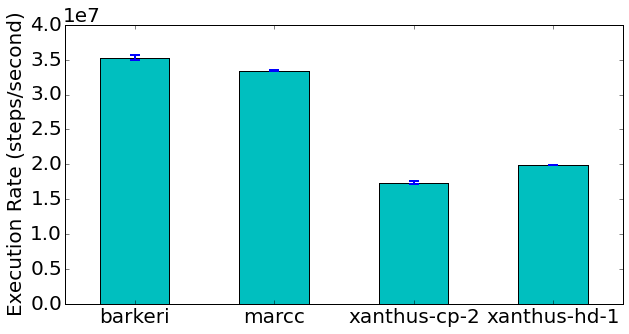

In [255]:
# Plot the latest timing data.
matplotlib.rcParams.update({'font.size': 20, "figure.figsize": (10,5)})
hosts = timingData.keys()
hosts.sort()
times=[]
timesErr=[]
for host in hosts:
    if "latest" in timingData[host]:
        times.append(mean(timingData[host]['latest']))
        timesErr.append(std(timingData[host]['latest']))
print times
plt.bar(arange(0,len(hosts))+0.25,times,width=0.5,yerr=timesErr, color='c', error_kw={"elinewidth":2,"capsize":5,"capthick":2})
plt.ylabel('Execution Rate (steps/second)')
plt.xticks(arange(0,len(hosts))+0.5, hosts)
plt.ylim([0,4e7])
pass

[17692727.272727273, 20564545.454545453, 20097272.727272727, 35293636.363636367]
[10250000.0, 17858181.818181816, 33424375.0]
[13435454.545454545, 14144545.454545455, 13266363.636363637, 17377142.857142858]
[16380000.0, 17122727.272727273, 16185454.545454545, 19931250.0]


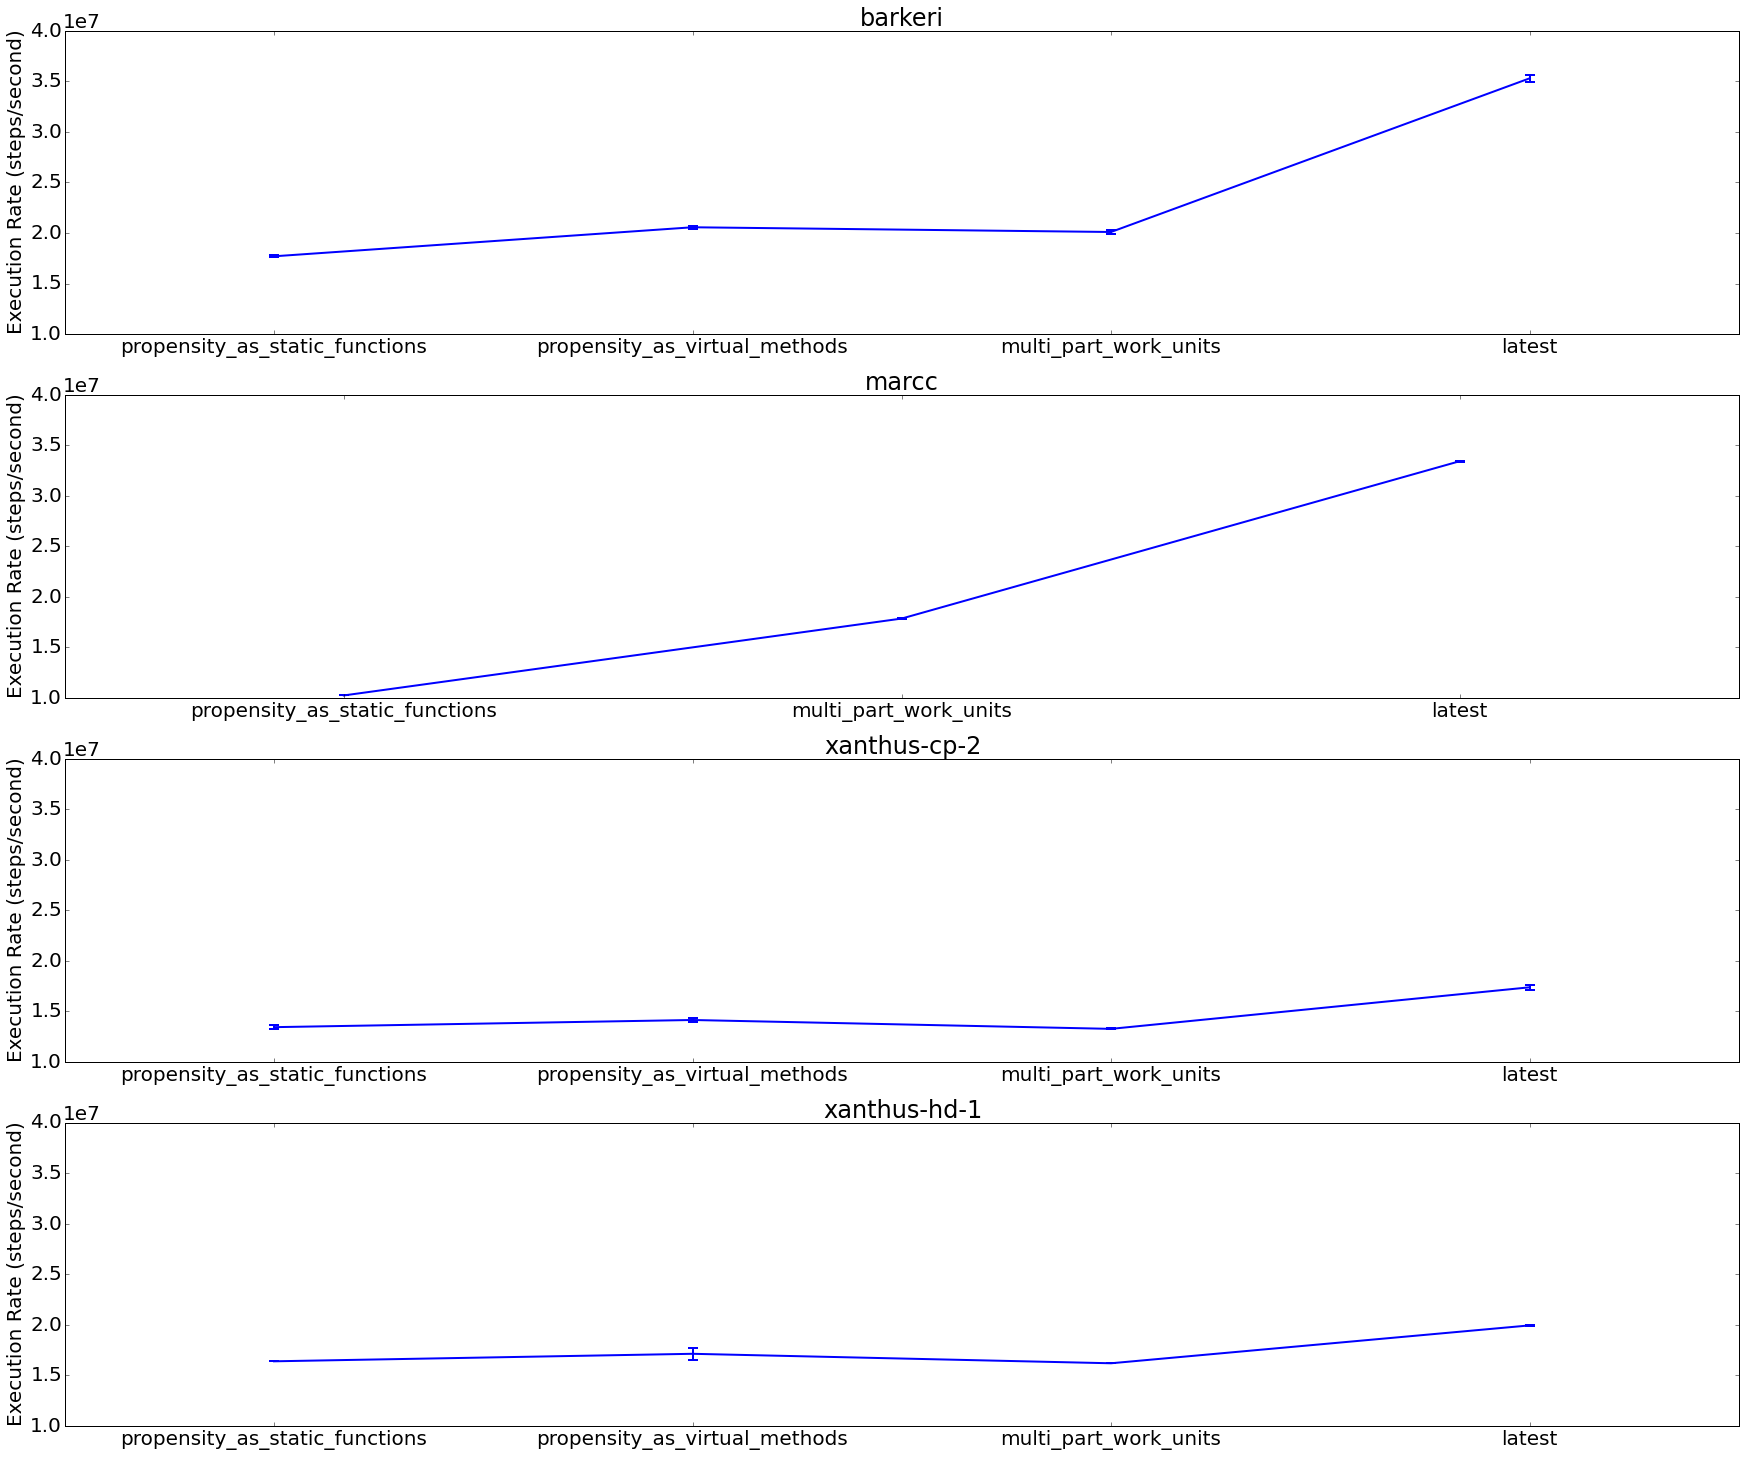

In [258]:
# Plot the previous timing data.
matplotlib.rcParams.update({'font.size': 20, "figure.figsize": (30,25)})
hosts = timingData.keys()
hosts.sort()
testNumbers = testNumberMap.keys()
testNumbers.sort()
for i,host in enumerate(hosts):
    times=[]
    timesErr=[]
    testNames=[]
    for testNumber in testNumbers:
        testName = testNumberMap[testNumber]
        if testName in timingData[host]:
            times.append(mean(timingData[host][testName]))
            timesErr.append(std(timingData[host][testName]))
            testNames.append(testName)
    plt.subplot(len(hosts),1,i+1)
    plt.errorbar(arange(0,len(testNames))+0.5,times,linewidth=2,yerr=timesErr,elinewidth=2,capsize=5,capthick=2)
    plt.ylabel('Execution Rate (steps/second)')
    plt.xticks(arange(0,len(testNames))+0.5, testNames)
    plt.xlim([0,len(testNames)]); plt.ylim([1e7,4e7])
    plt.title(host)
    print times
pass

### Performance comparison with a fully utilized node

In [274]:
%%bash
dirname=data/perf_full.99.latest
filename=${dirname}/first_order_birth_death.lm
mkdir -p ${dirname}
rm -f ${filename} && lm_sbml_import ${filename} first_order_birth_death.sbml
lm_setp ${filename} writeInterval=1e4 maxTime=1e5
cpus=24
trajectories=$((15*cpus))
echo "Execute the following command in `pwd`:"
echo "trajectories=${trajectories};"
echo 'for replicate in `seq -f "%g" 0 10`; do'
echo "echo Running \${replicate};"
#echo "hostname=\`hostname\`"
#echo "lmesPrefix=/share/git/LatticeMicrobesES/build/"
#echo "hostname=barkeri"
#echo "lmesPrefix="
echo "hostname=marcc"
echo "lmesPrefix=/home-2/erober32@jhu.edu/share/git/LatticeMicrobesES/build-icc/"
#echo "\${lmesPrefix}lmes -r 1-${trajectories} -f ${filename} -c ${cpus} -gr 0 -ff null -sl lm::cme::GillespieDSolver| tee ${filename}.\${hostname}.\${replicate}.log";
echo "\${lmesPrefix}lmes -r 1-${trajectories} -f ${filename} -c ${cpus} -gr 0 -ff null -sl lm::avx::GillespieDSolverAVX| tee ${filename}.\${hostname}.\${replicate}.log";
echo 'done;'


lm_sbml_import v2016.01.20 build 1
Copyright (C) 2008-2012 Luthey-Schulten Group, University of Illinois at Urbana-Champaign.
Copyright (C) 2012-2016 Roberts Group, Johns Hopkins University.


Done.
lm_setp v2016.01.20 build 1
Copyright (C) 2008-2012 Luthey-Schulten Group,
University of Illinois at Urbana-Champaign.

Setting parameters in simulation file data/perf_full.99.latest/first_order_birth_death.lm:
maxTime=1e5
writeInterval=1e4
Done.
Execute the following command in /Users/eroberts/Work/Lab/Git/LatticeMicrobesES/regression/first_order_birth_death:
trajectories=360;
for replicate in `seq -f "%g" 0 10`; do
echo Running ${replicate};
hostname=marcc
lmesPrefix=/home-2/erober32@jhu.edu/share/git/LatticeMicrobesES/build-icc/
${lmesPrefix}lmes -r 1-360 -f data/perf_full.99.latest/first_order_birth_death.lm -c 24 -gr 0 -ff null -sl lm::avx::GillespieDSolverAVX| tee data/perf_full.99.latest/first_order_birth_death.lm.${hostname}.${replicate}.log
done;


In [279]:
# Extract the timing data.
datadir="data"
timingDataFull={}
testNumberMapFull={}
regex0 = re.compile("perf_full\.(\d+).(\S+)")
regex1 = re.compile("\.lm\.([^\.]+)\.(\d+)\.log")
regex2 = re.compile("Finished .+ seconds \((\S+) steps/second\)")
for dirname in os.listdir(datadir):
    testName = None
    m = regex0.search(dirname)
    if m != None:
        testNumber = m.group(1)
        testName = m.group(2)
        testNumberMapFull[testNumber] = testName
    if testName is not None:
        for logname in os.listdir(datadir+"/"+dirname):
            m = regex1.search(logname)
            if m != None:
                host=m.group(1)
                replicate=int(m.group(2))
                with open(datadir+"/"+dirname+"/"+logname) as f:
                    for line in f:
                        m = regex2.search(line)
                        if m != None:
                            if host not in timingDataFull:
                                timingDataFull[host]={}
                            if testName not in timingDataFull[host]:
                                timingDataFull[host][testName]=[]
                            timingDataFull[host][testName].append(double(m.group(1)))
                            break

[33424375.0, 33419090.90909091]


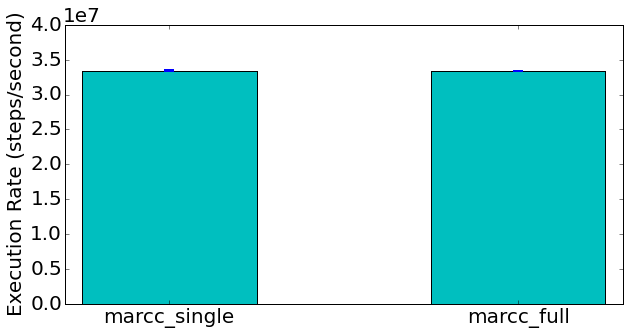

In [285]:
# Plot the latest timing data.
matplotlib.rcParams.update({'font.size': 20, "figure.figsize": (10,5)})
hosts = timingDataFull.keys()
hosts.sort()
times=[]
timesErr=[]
plotHosts=[]
for host in hosts:
    if "latest" in timingDataFull[host]:
        times.append(mean(timingData[host]['latest']))
        timesErr.append(std(timingData[host]['latest']))
        plotHosts.append("%s_%s"%(host,"single"))
        times.append(mean(timingDataFull[host]['latest']))
        timesErr.append(std(timingDataFull[host]['latest']))
        plotHosts.append("%s_%s"%(host,"full"))
print times
plt.bar(arange(0,len(plotHosts))+0.25,times,width=0.5,yerr=timesErr, color='c', error_kw={"elinewidth":2,"capsize":5,"capthick":2})
plt.ylabel('Execution Rate (steps/second)')
plt.xticks(arange(0,len(plotHosts))+0.5, plotHosts)
plt.ylim([0,4e7])
pass